In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
df = pd.read_csv('/content/drive/MyDrive/GROWTH/data_males.csv')

In [28]:
df.describe()

,measure_id,patient_medical_record,national_adi,state_adi,age_at_encounter,weight_measured,length_measured,LAZ,WAZ,WLZ,...,length_of_stay_days,length_of_stay_age,HOSP_count,age_at_encounter_months,n_day,range_weight,range_length,weight_measure,n_measures,first_visit
count,3.190000e+02,3.190000e+02,204.000000,204.000000,319.000000,319.000000,185.000000,185.000000,319.000000,185.000000,...,173.000000,173.000000,173.000000,319.000000,319.000000,319.000000,185.0,319.000000,319.000000,319.000000
mean,4.912584e+07,1.261010e+06,30.906863,5.602941,175.075235,6.592373,63.648108,-0.899405,-0.495878,0.156378,...,3.843931,174.913295,3.554913,5.759054,1.175549,0.000386,0.0,6.592494,6.893417,11.626959
std,6.939920e+06,1.822502e+05,19.233237,2.815193,163.380774,2.899887,9.737008,1.176033,1.274067,1.418460,...,7.079608,163.587323,2.080821,5.374368,0.405036,0.005653,0.0,2.900136,2.104485,7.297068
min,3.634618e+07,1.071521e+06,1.000000,1.000000,1.000000,2.285000,46.200000,-4.970000,-3.940000,-3.720000,...,0.000000,0.000000,1.000000,0.032895,1.000000,0.000000,0.0,2.285000,4.000000,1.000000
25%,4.294613e+07,1.121426e+06,18.250000,3.750000,22.000000,3.800000,54.390000,-1.610000,-1.315000,-0.890000,...,1.000000,16.000000,2.000000,0.723684,1.000000,0.000000,0.0,3.800000,5.000000,5.000000
50%,4.894635e+07,1.178622e+06,30.000000,6.000000,122.000000,6.180000,63.400000,-0.920000,-0.480000,0.150000,...,1.000000,125.000000,3.000000,4.013158,1.000000,0.000000,0.0,6.180000,6.000000,11.000000
75%,5.534607e+07,1.357742e+06,40.000000,8.000000,323.500000,9.055000,71.980000,-0.150000,0.330000,1.130000,...,3.000000,322.000000,4.000000,10.641447,1.000000,0.000000,0.0,9.055000,8.000000,18.000000
max,6.024640e+07,1.737070e+06,77.000000,10.000000,535.000000,14.400000,84.430000,1.690000,3.540000,4.450000,...,32.000000,535.000000,11.000000,17.598684,3.000000,0.100000,0.0,14.400000,10.000000,27.000000


In [21]:
df.groupby('patient_id')['patient_id'].nunique().count()

np.int64(51)

In [22]:
df.groupby('cleft_type')['patient_id'].nunique()


,patient_id
cleft_type,
CLEFT LIP,5
CLEFT LIP AND PALATE,29
CLEFT PALATE,17


In [23]:
def compute_slope(values, ages):
    """Linear slope of z-score over age — uses only non-null pairs."""
    mask = ~np.isnan(values)
    v, a = np.array(values)[mask], np.array(ages)[mask]
    if len(v) < 2:
        return np.nan
    return np.polyfit(a, v, 1)[0]

In [24]:
patient_features = df.groupby('patient_id').apply(lambda g: pd.Series({
    # WAZ features
    'WAZ_mean'  : g['WAZ'].mean(),
    'WAZ_min'   : g['WAZ'].min(),
    'WAZ_max'   : g['WAZ'].max(),
    'WAZ_std'   : g['WAZ'].std(),
    'WAZ_slope' : compute_slope(g['WAZ'].values, g['age_at_encounter_months'].values),
    # Age at encounter features
    'age_mean'  : g['age_at_encounter_months'].mean(),
    'age_min'   : g['age_at_encounter_months'].min(),
    'age_max'   : g['age_at_encounter_months'].max(),
    'age_span'  : g['age_at_encounter_months'].max() - g['age_at_encounter_months'].min(),
    # Visit quality
    'n_visits'  : g['WAZ'].notna().sum(),
    # Demographics
    'race'      : g['race'].iloc[0],
    'ethnicity' : g['ethnicity'].iloc[0],
    'cleft_type': g['cleft_type'].iloc[0],
    'syndrome'  : g['syndrome'].iloc[0],
}), include_groups=False).reset_index()

print(f"Patient feature matrix shape: {patient_features.shape}")
patient_features.head()

Patient feature matrix shape: (51, 15)


,patient_id,WAZ_mean,WAZ_min,WAZ_max,WAZ_std,WAZ_slope,age_mean,age_min,age_max,age_span,n_visits,race,ethnicity,cleft_type,syndrome
0,Z1021283,-1.155000,-1.83,-0.13,0.723257,0.147375,6.036184,0.789474,12.565789,11.776316,4,Alaska Native,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
1,Z1029082,-0.757500,-1.13,-0.14,0.428904,-0.054011,9.457237,0.427632,17.203947,16.776316,4,Asian,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
2,Z1036313,-2.082500,-3.17,0.14,1.311082,0.239202,4.403783,0.394737,15.131579,14.736842,8,White,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
3,Z1042984,0.468333,-1.22,2.04,1.366696,0.200164,6.578947,0.460526,11.875000,11.414474,6,White,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
4,Z1055588,-0.615000,-1.48,0.31,0.676498,-0.073247,8.358553,0.098684,17.236842,17.138158,10,White,Non-Hispanic,CLEFT PALATE,SYNDROMIC


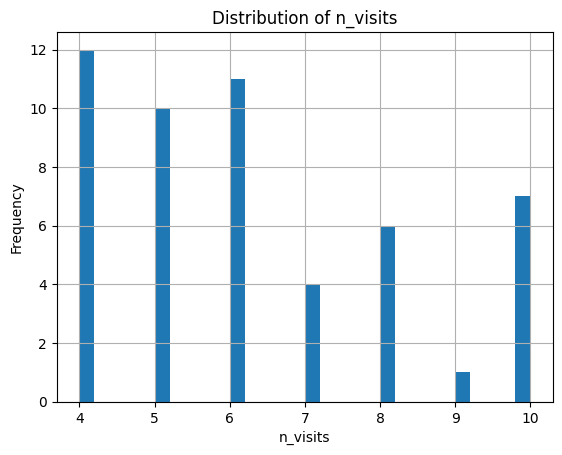

In [31]:
patient_features['n_visits'].hist(bins=30)
plt.xlabel('n_visits')
plt.ylabel('Frequency')
plt.title('Distribution of n_visits')
plt.show()

In [32]:
patient_features['n_visits'].value_counts()

,count
n_visits,
4,12
6,11
5,10
10,7
8,6
7,4
9,1


In [25]:
# One-hot encode categorical columns
race_dummies     = pd.get_dummies(patient_features['race'],       prefix='race')
ethnicity_dummies = pd.get_dummies(patient_features['ethnicity'], prefix='ethnicity')
cleft_dummies    = pd.get_dummies(patient_features['cleft_type'], prefix='cleft')
syndrome_dummies = pd.get_dummies(patient_features['syndrome'],   prefix='syndrome')

# Concatenate all dummies and drop original text columns
patient_features = pd.concat(
    [patient_features, race_dummies, ethnicity_dummies, cleft_dummies, syndrome_dummies],
    axis=1
)
patient_features = patient_features.drop(columns=['race', 'ethnicity', 'cleft_type', 'syndrome'])

print("Encoded race columns:     ", list(race_dummies.columns))
print("Encoded ethnicity columns:", list(ethnicity_dummies.columns))
print("Encoded cleft columns:    ", list(cleft_dummies.columns))
print("Encoded syndrome columns: ", list(syndrome_dummies.columns))

Encoded race columns:      ['race_Alaska Native', 'race_Asian', 'race_Black or African American', 'race_Native Hawaiian and Other Pacific Islander', 'race_Other', 'race_Unknown', 'race_White']
Encoded ethnicity columns: ['ethnicity_Hispanic', 'ethnicity_Non-Hispanic']
Encoded cleft columns:     ['cleft_CLEFT LIP', 'cleft_CLEFT LIP AND PALATE', 'cleft_CLEFT PALATE']
Encoded syndrome columns:  ['syndrome_ISOLATED', 'syndrome_ROBIN', 'syndrome_SYNDROMIC']


In [ ]:
# ── Step 3: Assemble final feature matrix ──────────────────────────────────────

# Numeric trajectory + age features only — demographics excluded from clustering
# (demographics will be used AFTER clustering to interpret/describe groups)
numeric_cols = [
    'WAZ_mean', 'WAZ_min', 'WAZ_max', 'WAZ_std', 'WAZ_slope',
    'age_mean', 'age_min', 'age_max', 'age_span', 'n_visits'
]

all_cluster_cols = numeric_cols
print(f"Total features going into K-means: {len(all_cluster_cols)}")

X = patient_features[all_cluster_cols].copy()
X = X.fillna(X.median())

# Standardise — essential so age features don't dominate over WAZ features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:

# ── 1. Reduce to most clinically meaningful features ───────────────────────────
core_cols = ['WAZ_mean', 'WAZ_slope', 'WAZ_min', 'age_span', 'n_visits']

X_core = patient_features[core_cols].copy()
X_core = X_core.fillna(X_core.median())

scaler_core = StandardScaler()
X_core_scaled = scaler_core.fit_transform(X_core)

# ── 2. PCA to 2D for visualization ────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_core_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}")



In [ ]:
# ── 3. Re-run K-means on reduced features ─────────────────────────────────────
K_values    = [2, 3, 4, 5, 6]
results     = {}
inertias    = []
silhouettes = []

for k in K_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, max_iter=500, random_state=42)
    labels = km.fit_predict(X_core_scaled)
    inertia    = km.inertia_
    sil_score  = silhouette_score(X_core_scaled, labels)
    results[k] = {'labels': labels, 'inertia': inertia, 'silhouette': sil_score, 'model': km}
    inertias.append(inertia)
    silhouettes.append(sil_score)
    print(f"K={k} | Inertia: {inertia:.1f} | Silhouette: {sil_score:.3f} "
          f"| Cluster sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")





In [ ]:
# ── Assign best K=2 cluster labels to patient_features ── ADD THIS LINE HERE
patient_features['cluster'] = results[2]['labels']

# ── 4. PCA scatter plot coloured by K=2 labels ────────────────────────────────
best_labels = results[2]['labels']
print(f"K={k} | Inertia: {inertia:.1f} | Silhouette: {sil_score:.3f} "
    f"| Cluster sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")

In [ ]:
# ── Step 3: Elbow + Silhouette plots to guide K selection ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_values, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_title('Elbow Method — Inertia by K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].grid(alpha=0.3)
for k, inertia in zip(K_values, inertias):
    axes[0].annotate(f'{inertia:.0f}', (k, inertia),
                     textcoords='offset points', xytext=(0, 10), ha='center')

# Silhouette scores
axes[1].plot(K_values, silhouettes, 'rs-', linewidth=2.5, markersize=8)
axes[1].set_title('Silhouette Score by K\n(higher = better separated clusters)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
for k, s in zip(K_values, silhouettes):
    axes[1].annotate(f'{s:.3f}', (k, s),
                     textcoords='offset points', xytext=(0, 10), ha='center')

best_k = K_values[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='red', linestyle='--',
                linewidth=1.5, label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('K Selection Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: K={best_k} ({max(silhouettes):.3f})")

In [ ]:
# ── 4. PCA scatter plot coloured by K=2 labels ────────────────────────────────
best_labels = results[2]['labels']
colors      = ['steelblue', 'coral']
color_map   = [colors[l] for l in best_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA scatter coloured by cluster
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color_map, s=80, edgecolors='white', linewidths=0.8)
patches = [mpatches.Patch(color=colors[i], label=f'Cluster {i}') for i in range(2)]
ax.legend(handles=patches, frameon=False)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA — K=2 Cluster Assignment')
ax.spines[['top', 'right']].set_visible(False)

# Right: Silhouette scores across K
ax2 = axes[1]
ax2.plot(K_values, silhouettes, marker='o', color='steelblue', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by K')
ax2.set_xticks(K_values)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Rebuild demographic columns from data_cohort
demo = df.groupby('patient_id')[['race', 'ethnicity', 'cleft_type', 'syndrome', 'sex']].first().reset_index()

# Merge back into patient_features
patient_features = patient_features.merge(demo, on='patient_id', how='left')

# Verify
print(patient_features[['patient_id', 'cluster', 'race', 'ethnicity', 'cleft_type', 'syndrome', 'sex']].head())

In [ ]:
print("Mean trajectory features per cluster:")
display(patient_features.groupby('cluster')[core_cols].mean().round(3))

print("\nRace distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['race'],
                    normalize='index').round(3) * 100)

print("\nEthnicity distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['ethnicity'],
                    normalize='index').round(3) * 100)

print("\nCleft type distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['cleft_type'],
                    normalize='index').round(3) * 100)

print("\nSyndrome distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['syndrome'],
                    normalize='index').round(3) * 100)

print("\nSex distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['sex'],
                    normalize='index').round(3) * 100)